# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

In [1]:
! git clone https://github.com/smerashanmugan/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 43 (delta 13), reused 6 (delta 6), pack-reused 26 (from 2)
Receiving objects: 100% (43/43), 122.17 KiB | 3.70 MiB/s, done.
Resolving deltas: 100% (14/14), done.
Download complete
Extracting data files...
Data extracted


1.  A model is called linear because the parameters are linear.Using the linear format equation for a model, linear is referring to the fact that the coefficients are added together while being multipled by the variables.
2. A dummy variable coefficient is indicating that there is a difference in the outcome compared to the refernce group. the intercept is the expected y value for the basleine while the cumy coefficient is referring to the higher or lower relative baseline to y.
3. It would not be ideal to use linear regression for classification because the predictions would have no bounds and linear regression assumes a linear relationship but it may not be, and any errors will not be modeled correctly.
4. Some signs that your linear model is overfitting are that they have a high training accuracy but poor test performance, the model is very sensitive to small data changes, and coefficients are not stabel and complex models are produced.
5. Multicollinearity identifies predictors as highly correlated with one another which makes it hard to isolate individual contributions or effects. First, you regress one predictor on other predictors and then you get the predicted part and the residual. Then use the residual to estimate the effect on y. If multicollinearity is present the residual will be small and coefficient estimates become unstable.
6. You can incoporate nonlinear relationships with linear regression by transforming variables such as polynomials where x^2 becomes x^3 and incorporating log(x).
7. The slope coefficeint in a linear regression represents a change in y for one unit increase in x while all of the other variables are constant.
8. The train/test split, splits the data once and the model is trained on the training set while it is being evaluated on the test set. This model is simpla and fast but the results are dependent on how the data is split which means that unstable estimates can be made with a small dataset. The k-Fold Cross-Validation divides data in k equal parts and the model is trained k times, and each time using a different fold as the test set and the remaining folds as the training data. The final result is the acerage across all k runs and this model is able to provide more reliable and stable estimates compares to the train/test split.

9. The most common k values used are k=5 or 10 with 10 being the standard default. a smaller k value would be used with larger dataest because you want to compute the data fastes while larger k values(give us a low bias) but have a high variance.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/Q1_clean.csv")
df = df.rename(columns={"Price per night": "price","Review Scores Rating": "rating","Neighbourhood": "neighbourhood"
})
print(df.columns)
summary = (
    df.groupby("Neighbourhood ")
      .agg(
          avg_price=("Price", "mean"),
          avg_rating=("rating", "mean")
      )
      .sort_values("avg_price", ascending=False)
)

print(summary)

Index(['Price', 'rating', 'Neighbourhood ', 'Property Type', 'Room Type'], dtype='object')
                 avg_price  avg_rating
Neighbourhood                         
Manhattan       183.664286   91.801496
Staten Island   146.166667   90.843750
Brooklyn        127.747378   92.363497
Queens           96.857233   91.549057
Bronx            75.276498   91.654378


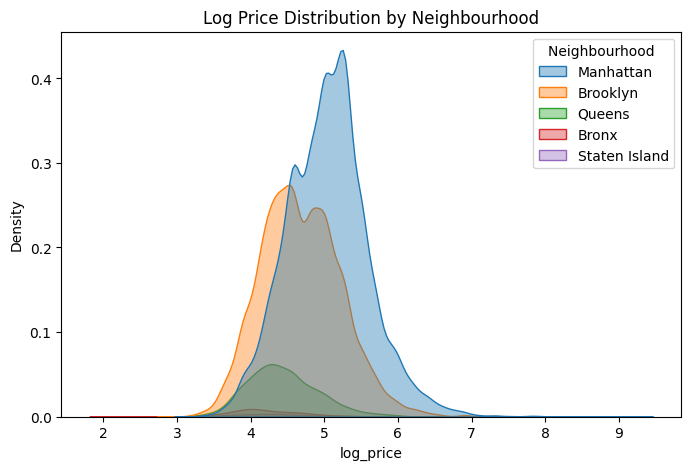

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["log_price"] = np.log(df["Price"])

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="log_price", hue="Neighbourhood ", fill=True, alpha=0.4)
plt.title("Log Price Distribution by Neighbourhood")
plt.show()

1. Manhattan has the highest average price which makes it the most expensive borough on average.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["Price", "rating", "Neighbourhood "])
y = df["Price"]
X = pd.get_dummies(df["Neighbourhood "], drop_first=True)
X = X.astype(float)
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print("\nRegression Results:\n")
print(model.summary())


Regression Results:

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        19:58:38   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765

2. The regression uses dummy variables for neighborhood and one category(Bronx) was dropped to avoid the dummy variable trap The regression shows the intercept to be 75.28 which matches the price average for the Bronx from part 1. The coefficients in the the regression represent the difference in the average prices relative to the Bronx.These values all match with the averages found in part 1. The regression coefficeints correspond to the differences in the group means and adding those to the intercept recovers the average price for each neighborhood. The regressions coefficients represent differences in the conditional group means relative to the reference category.

In [22]:
import statsmodels.api as sm

y = df["Price"]

X = sm.add_constant(df["rating"])

model_rating = sm.OLS(y, X).fit()
print(model_rating.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        20:05:42   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         60.8784     10.423      5.841      0.0

3. The slope coefficient is 1.0208 which signifies that there is a 1 point increase in the review scores that is associated with an increase of 1.02 dollars on average.

In [23]:
import statsmodels.api as sm
import pandas as pd

y = df["Price"]
X = pd.get_dummies(df["Neighbourhood "], drop_first=True)
X["rating"] = df["rating"]
X = X.astype(float)
X = sm.add_constant(X)

model_full = sm.OLS(y, X).fit()
print(model_full.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        20:09:29   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -23.8126     14.105     -1.688

4. When price is regressed on both the neighborhood and review scors rating, the slope coefficient on rating is 1.0811 compared to the 1.0208 with just the rating alons. The slight change in the coefficient indicates that being able to control for neighborhood is able to isolate the effect of rating within each borough. The neighborhood coefficients remain very similar to the previous model and represent differrences in the price relative to the reference group, Bronx. However, the interpretation changes where they represent the differences in price while the rating is held constant.

In [28]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(df.columns)
import statsmodels.formula.api as smf

model_interact = smf.ols("price ~ neighbourhood * rating", data=df).fit()
print(model_interact.summary())

Index(['price', 'rating', 'neighbourhood', 'property_type', 'room_type',
       'log_price'],
      dtype='object')
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:16:52   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025 

5. The slopes are similar across most neighborhoods, except for Staten Island which shows a different relationship between rating and price.

In [29]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd


kf = KFold(n_splits=10, shuffle=True, random_state=1)
lr = LinearRegression()

y = df["price"]

X1 = pd.get_dummies(df["neighbourhood"], drop_first=True)
X1 = X1.astype(float)

cv1 = cross_val_score(lr, X1, y, cv=kf, scoring="neg_mean_squared_error")
rmse1 = np.sqrt(-cv1.mean())

X2 = df[["rating"]]

cv2 = cross_val_score(lr, X2, y, cv=kf, scoring="neg_mean_squared_error")
rmse2 = np.sqrt(-cv2.mean())


X3 = pd.get_dummies(df["neighbourhood"], drop_first=True)
X3["rating"] = df["rating"]
X3 = X3.astype(float)

cv3 = cross_val_score(lr, X3, y, cv=kf, scoring="neg_mean_squared_error")
rmse3 = np.sqrt(-cv3.mean())


print("Model 4 (Neighbourhood):", rmse1)
print("Model 5 (Rating):", rmse2)
print("Model 6 (Both):", rmse3)

Model 4 (Neighbourhood): 145.43502996678467
Model 5 (Rating): 148.57963061535204
Model 6 (Both): 145.13993148609902


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


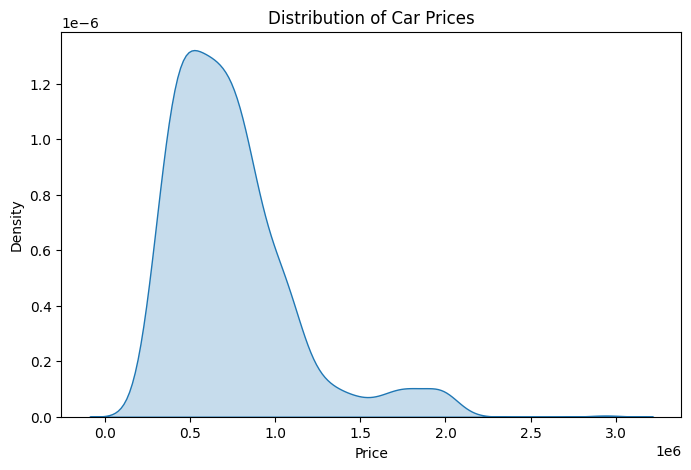

           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


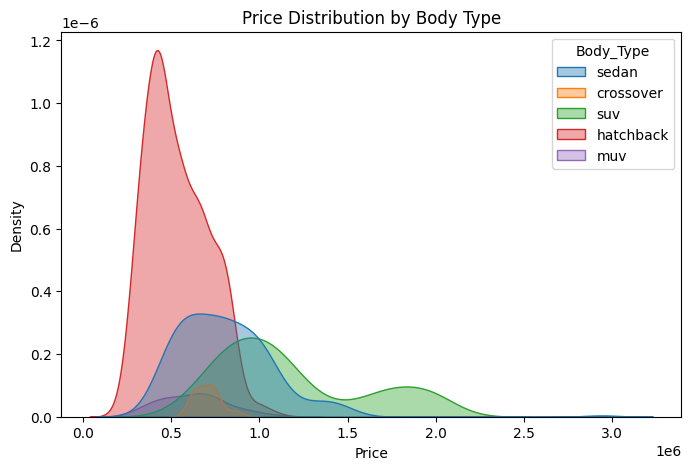

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("./data/cars_hw.csv")

print(df["Price"].describe())
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="Price", fill=True)
plt.title("Distribution of Car Prices")
plt.show()
group_summary = df.groupby("Body_Type")["Price"].describe()
print(group_summary)
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="Price", hue="Body_Type", fill=True, alpha=0.4)
plt.title("Price Distribution by Body Type")
plt.show()

1. SUVs and Sedans are the most expensive and they also have the highest variance.

In [37]:
import statsmodels.api as sm
import pandas as pd
y = df["Price"]
X = sm.add_constant(df["Seating_Capacity"])

model_seat = sm.OLS(y, X).fit()
print(model_seat.summary())

y = pd.to_numeric(df["Price"], errors="coerce")

X_cat = pd.get_dummies(df["Seating_Capacity"], drop_first=True)

X_cat = X_cat.astype(float)

X_cat = sm.add_constant(X_cat)

model_cat = sm.OLS(y, X_cat).fit()
print(model_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0245
Time:                        21:09:21   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              4.39e+05   1.35e+05  

2. the slope coefficient on seating_capacity is 59,270 rupees meaning that each additional seat is associated with an increase of about 59,270 rupees in price.The differences in price are not linear in the number of seats and this is because the pattern in the increase of seats is not consistent.

In [38]:
current_year = df["Make_Year"].max()
df["Age"] = current_year - df["Make_Year"]
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

kf = KFold(n_splits=10, shuffle=True, random_state=1)

y = df["Price"]

rmse_results = {}

# Test polynomial degrees 1 to 4
for d in range(1, 5):

    X_poly = pd.DataFrame()

    for i in range(1, d+1):
        X_poly[f"Age^{i}"] = df["Age"]**i

    model = LinearRegression()

    scores = cross_val_score(
        model,
        X_poly,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )

    rmse = np.sqrt(-scores.mean())
    rmse_results[d] = rmse

print(rmse_results)

{1: np.float64(312643.18321601185), 2: np.float64(312754.4077264401), 3: np.float64(311936.0131251042), 4: np.float64(311103.4963939869)}


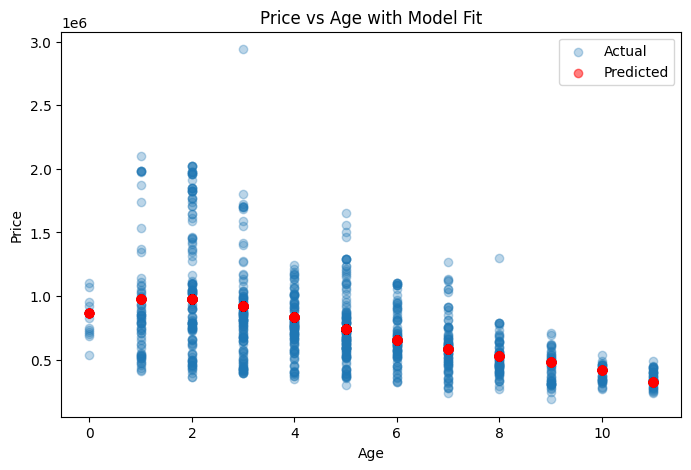

In [39]:
from sklearn.linear_model import LinearRegression
X = pd.DataFrame()
for i in range(1, 5):
    X[f"Age^{i}"] = df["Age"]**i

y = df["Price"]
model = LinearRegression()
model.fit(X, y)

df["predicted_price"] = model.predict(X)
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Price"], alpha=0.3, label="Actual")

plt.scatter(df["Age"], df["predicted_price"], color="red", alpha=0.5, label="Predicted")

plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age with Model Fit")
plt.legend()
plt.show()

4. No it does not accurately predict the data because the model fits the general trends pretty well but is unable to capture the high variability in prices.

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [40]:
import pandas as pd

df = pd.read_csv("./data/heart_hw.csv")

control_mean = df[df["transplant"] == "control"]["y"].mean()

treat_mean = df[df["transplant"] == "treatment"]["y"].mean()

ATE = treat_mean - control_mean

print("Control:", control_mean)
print("Treatment:", treat_mean)
print("ATE:", ATE)

Control: 0.11764705882352941
Treatment: 0.34782608695652173
ATE: 0.23017902813299232


1. The ATE on 3 year survival for heart transplant interventions is approximately 0.230.

In [41]:
import statsmodels.formula.api as smf

model1 = smf.ols("y ~ transplant", data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Tue, 24 Mar 2026   Prob (F-statistic):             0.0133
Time:                        21:20:48   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

2. Regressing y on transplant status, the intercept is 0.1176 and the coefficeint on the transplant variable is 0.2302. Both of these values match the results from part 1 where the control groups survival rate is 0.118 and the ATE is 0.230.

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000357
Time:                        21:24:45   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

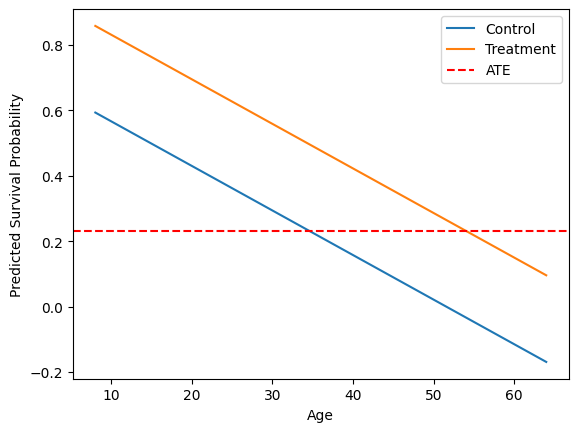

In [43]:
model2 = smf.ols("y ~ transplant + age", data=df).fit()
print(model2.summary())
import numpy as np
import matplotlib.pyplot as plt

ages = np.linspace(df["age"].min(), df["age"].max(), 100)

pred_control = model2.predict(pd.DataFrame({"age": ages, "transplant": "control"}))
pred_treat = model2.predict(pd.DataFrame({"age": ages, "transplant": "treatment"}))

plt.plot(ages, pred_control, label="Control")
plt.plot(ages, pred_treat, label="Treatment")

plt.axhline(y=ATE, linestyle="--", color="red", label="ATE")

plt.xlabel("Age")
plt.ylabel("Predicted Survival Probability")
plt.legend()
plt.show()

3. The coefficient on transplant increases from 0.230 to 0.265 which indicates that the age was a confounding variable. The intrecept represents the predicted survival probability for a control patient at age 0. The slope represents the survival probability decreasing by 1.36% points per additional year of age.At younger ages,the ATE underestimates the benefit of transplant and at older ages the ATE overestimates the benefit.

In [44]:
model3 = smf.ols("y ~ transplant * age", data=df).fit()
print(model3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Tue, 24 Mar 2026   Prob (F-statistic):           0.000310
Time:                        21:29:40   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept         

4. When including an interaction between transplant and age, the the effect of transplant is no longer constant across ages. The pattern shows that transplant is most beneficial for younger people and is less effective for older people and because of the the prediction changes to the idea that the beneift of transplant declines with age(strongest for younger people).

In [45]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

kf = KFold(n_splits=10, shuffle=True, random_state=1)
y = df["y"]

X1 = pd.get_dummies(df["transplant"], drop_first=True)
cv1 = cross_val_score(LinearRegression(), X1, y, cv=kf, scoring="neg_mean_squared_error")

X2 = X1.copy()
X2["age"] = df["age"]
cv2 = cross_val_score(LinearRegression(), X2, y, cv=kf, scoring="neg_mean_squared_error")

X3 = X2.copy()
X3["interaction"] = X3.iloc[:,0] * X3["age"]
cv3 = cross_val_score(LinearRegression(), X3, y, cv=kf, scoring="neg_mean_squared_error")

print(np.sqrt(-cv1.mean()), np.sqrt(-cv2.mean()), np.sqrt(-cv3.mean()))

0.44155689991429364 0.42339598433324993 0.42284993511312424


6. The model may have selection bias which is concerning for the fairness due to age based decisions and and has limited predictive accuracy and could reinforce healthcare inequalities.